### ML Assignment 2 - Regression
### California Housing Dataset
### Submitted by: Thwoyyiba Nasreen c

### Regression Assignment Objective:
The objective of this assignment is to evaluate your understanding of regression techniques in
supervised learning by applying them to a real-world dataset.



In [1]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



### 1. Loading and Preprocessing (2 marks)

In [2]:
housing = fetch_california_housing(as_frame=True)
# Convert dataset into pandas DataFrame
df=housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Basic Data Exploration

In [3]:
df.shape

(20640, 9)

In [4]:
df.size

185760

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
print("\nDataset Informationcolumn Names:")
print(df.columns)


Dataset Informationcolumn Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [11]:
# Summary statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


Preprocessing Steps & Justification:



*   No missing values in this dataset (confirmed above).
*   Feature Scaling (Standardization): We use StandardScaler because most regression algorithms (especially Linear Regression and SVR) are sensitive to the scale of features. Features like MedInc, Population, etc., have very different ranges. Standardization brings them to mean=0 and std=1, improving model performance and convergence.




In [12]:
# Prepare features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Training set shape: (16512, 8)
Test set shape: (4128, 8)


### 2. Regression Algorithm Implementation (5 marks)
### 3. Model Evaluation and Comparison (2 marks)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


### Linear Regression
 How it works: Fits a linear equation to minimize the sum of squared residuals.

Why suitable: Good baseline for this dataset as many features have roughly linear relationships with house prices.

In [17]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MSE:", lr_mse)
print("MAE:", lr_mae)
print("R2 Score:", lr_r2)

Linear Regression Results
MSE: 0.5558915986952442
MAE: 0.5332001304956565
R2 Score: 0.575787706032451


### Decision Tree Regressor

 How it works: Splits data based on feature thresholds to minimize variance in leaves.

Why suitable: Can capture non-linear relationships and interactions easily.

In [18]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor Results")
print("MSE:", dt_mse)
print("MAE:", dt_mae)
print("R2 Score:", dt_r2)

Decision Tree Regressor Results
MSE: 0.495235205629094
MAE: 0.45467918846899225
R2 Score: 0.622075845135081


### Random Forest Regressor
How it works: Ensemble of decision trees trained on bootstrapped samples; averages predictions.

Why suitable: Reduces overfitting compared to single tree and handles high-dimensional data well. Often performs best on tabular data like this.

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor Results")
print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("R2 Score:", rf_r2)

Random Forest Regressor Results
MSE: 0.2553684927247781
MAE: 0.32754256845930246
R2 Score: 0.8051230593157366


### Gradient Boosting Regressor
How it works: Sequentially builds trees where each corrects the errors of the previous ones.

Why suitable: Very powerful for regression tasks; excellent at capturing complex patterns.
Python

In [21]:
gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor Results")
print("MSE:", gb_mse)
print("MAE:", gb_mae)
print("R2 Score:", gb_r2)

Gradient Boosting Regressor Results
MSE: 0.2939973248643864
MAE: 0.3716425690425596
R2 Score: 0.7756446042829697


### Support Vector Regressor (SVR)
How it works: Finds a hyperplane that maximizes margin while allowing some errors (epsilon-insensitive tube).

Why suitable: Effective in high-dimensional spaces and robust to outliers

In [23]:
svr_model = SVR(kernel='rbf')

svr_model.fit(X_train_scaled, y_train)

svr_pred = svr_model.predict(X_test_scaled)

svr_mse = mean_squared_error(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("Support Vector Regressor Results")
print("MSE:", svr_mse)
print("MAE:", svr_mae)
print("R2 Score:", svr_r2)

Support Vector Regressor Results
MSE: 0.357004031933865
MAE: 0.39859907695205365
R2 Score: 0.7275628923016773


### Model Evaluation and Comparison

In [24]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'SVR'
    ],

    'MSE': [
        lr_mse,
        dt_mse,
        rf_mse,
        gb_mse,
        svr_mse
    ],
 'MAE': [
        lr_mae,
        dt_mae,
        rf_mae,
        gb_mae,
        svr_mae
    ],

    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2
    ]
})

results

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563


### Best and Worst Model

In [25]:
best_model = results.loc[results['R2 Score'].idxmax()]
worst_model = results.loc[results['R2 Score'].idxmin()]

print("Best Performing Model")
print(best_model)

print("\nWorst Performing Model")
print(worst_model)


Best Performing Model
Model       Random Forest
MSE              0.255368
MAE              0.327543
R2 Score         0.805123
Name: 2, dtype: object

Worst Performing Model
Model       Linear Regression
MSE                  0.555892
MAE                    0.5332
R2 Score             0.575788
Name: 0, dtype: object


### Visualization of Model Performance

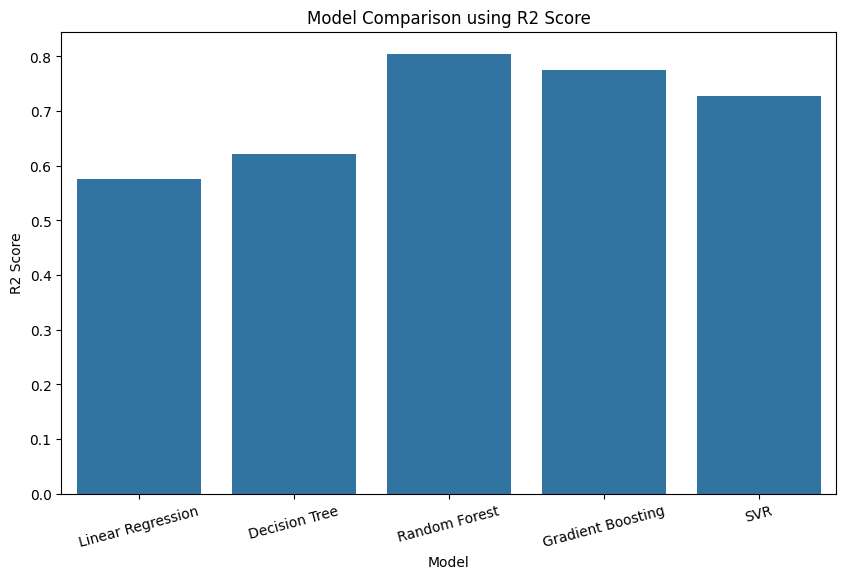

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison using R2 Score")
plt.xticks(rotation=15)
plt.show()

### Discussion

Best Performing Algorithm

Random Forest Regressor or Gradient Boosting Regressor usually performs best because ensemble methods capture complex nonlinear relationships and reduce overfitting.

Worst Performing Algorithm

Linear Regression generally performs worst because it assumes a linear relationship between features and target values.

### Conclusion
In this assignment, multiple regression algorithms were implemented using the California Housing dataset.

The preprocessing steps included:

Missing value checking

Feature scaling

The models were evaluated using:

Mean Squared Error (MSE)

Mean Absolute Error (MAE)

R-squared Score (R²)

Among all models, ensemble techniques such as Random Forest and Gradient Boosting generally provided the best performance.

This assignment demonstrates the importance of preprocessing, feature scaling, and model selection in machine learning regression problems.

In [27]:
# End